# Practice 07 — Particle Filter

구성:
1. **Practice 1-1** — True state simulation  
2. **Practice 1-2** — Bearing sensor measurement simulation  
3. **Practice 2** — Particle Filter with Dead Reckoning Model  
4. **Practice 3** — RMSE comparison: EKF-CV / EKF-DR / PF-DR  

문제에서 요구한 시각화만 포함:
- Practice 1-1: 각 state 및 2D vehicle position
- Practice 1-2: measurement simulation result
- Practice 2: estimated state 및 estimation error
- Practice 3: RMSE comparison 출력


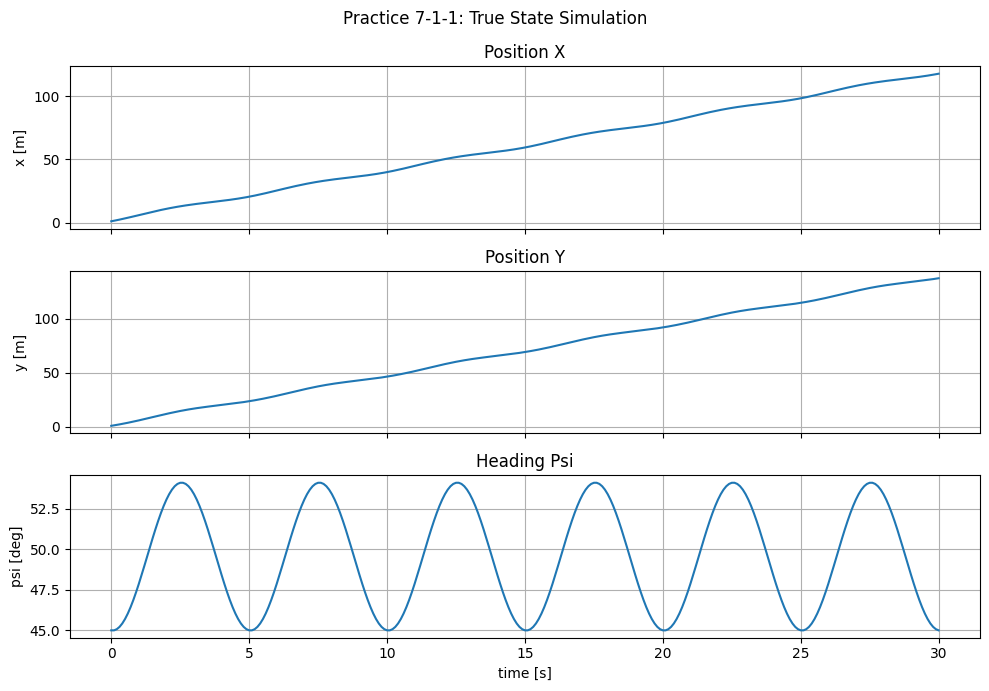

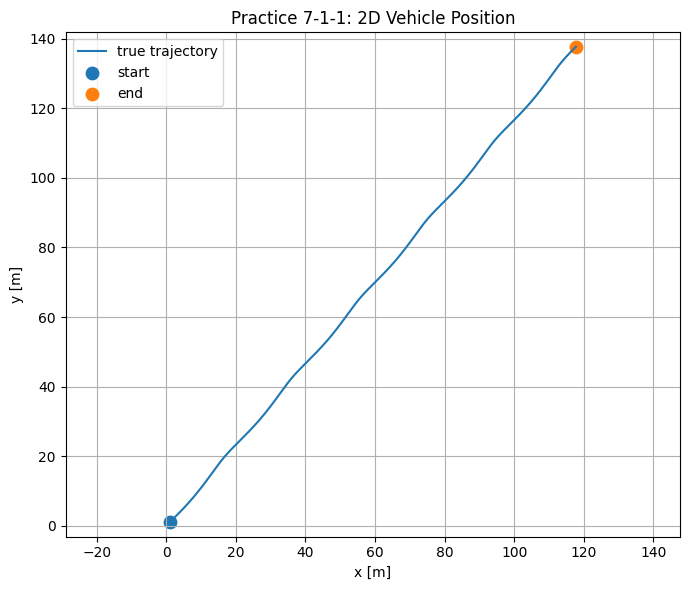

Practice 7-1-1 Result Check
dT                  : 0.1 s
t_end               : 30.0 s
N                   : 301
x_history shape     : (301, 3)
final position      : x = 117.702 m, y = 137.668 m
final heading       : psi = 45.000 deg


In [6]:
# ============================================================
# Practice 7-1-1
# True State Simulation for 2D Vehicle
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1️⃣ 공통 함수 정의
# ============================================================

def wrap_angle(angle):
    """
    angle을 -pi ~ pi 범위로 변환
    """
    return (angle + np.pi) % (2.0 * np.pi) - np.pi


# ============================================================
# 2️⃣ 시뮬레이션 조건 설정
#    Practice 6과 동일 조건 사용
# ============================================================

dT = 0.1
t_end = 30.0
t = np.arange(0.0, t_end + dT, dT)
N = len(t)


# ============================================================
# 3️⃣ 입력 데이터 생성
#    Practice 6과 동일 input 사용
#    velocity: 평균 6 m/s, 진폭 2 m/s, 주기 5초
#    yaw rate: 진폭 0.1 rad/s, 주기 5초
# ============================================================

V = 6.0 + 2.0 * np.sin(2.0 * np.pi * t / 5.0)
psi_dot = 0.1 * np.sin(2.0 * np.pi * t / 5.0)

# ============================================================
# 4️⃣ True State Simulation
#    State = [x, y, psi]^T
#    initial condition: x0 = 1 m, y0 = 1 m, psi0 = 45 deg
# ============================================================

x_history = np.zeros((N, 3))
x_history[0, 0] = 1.0
x_history[0, 1] = 1.0
x_history[0, 2] = np.deg2rad(45.0)

for k in range(1, N):
    x_prev = x_history[k - 1, 0]
    y_prev = x_history[k - 1, 1]
    psi_prev = x_history[k - 1, 2]
    
    V_prev = V[k - 1]
    psi_dot_prev = psi_dot[k - 1]
    
    x_new = x_prev + V_prev * dT * np.cos(psi_prev)
    y_new = y_prev + V_prev * dT * np.sin(psi_prev)
    psi_new = wrap_angle(psi_prev + psi_dot_prev * dT)
    
    x_history[k] = [x_new, y_new, psi_new]

# ============================================================
# 5️⃣ 결과 시각화 ① — 각 state 시간 그래프
#    문제 요구: each state plot
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

axes[0].plot(t, x_history[:, 0], linewidth=1.5)
axes[0].set_title("Position X")
axes[0].set_ylabel("x [m]")
axes[0].grid(True)

axes[1].plot(t, x_history[:, 1], linewidth=1.5)
axes[1].set_title("Position Y")
axes[1].set_ylabel("y [m]")
axes[1].grid(True)

axes[2].plot(t, np.rad2deg(x_history[:, 2]), linewidth=1.5)
axes[2].set_title("Heading Psi")
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("psi [deg]")
axes[2].grid(True)

plt.suptitle("Practice 7-1-1: True State Simulation")
plt.tight_layout()
plt.show()

# ============================================================
# 6️⃣ 결과 시각화 ② — 2D vehicle position
#    문제 요구: 2D vehicle position plot
# ============================================================

plt.figure(figsize=(7, 6))
plt.plot(x_history[:, 0], x_history[:, 1], linewidth=1.5, label="true trajectory")
plt.scatter(x_history[0, 0], x_history[0, 1], s=80, label="start")
plt.scatter(x_history[-1, 0], x_history[-1, 1], s=80, label="end")
plt.title("Practice 7-1-1: 2D Vehicle Position")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 7️⃣ 결과 확인
# ============================================================

print("=" * 60)
print("Practice 7-1-1 Result Check")
print("=" * 60)
print(f"dT                  : {dT} s")
print(f"t_end               : {t_end} s")
print(f"N                   : {N}")
print(f"x_history shape     : {x_history.shape}")
print(f"final position      : x = {x_history[-1,0]:.3f} m, y = {x_history[-1,1]:.3f} m")
print(f"final heading       : psi = {np.rad2deg(x_history[-1,2]):.3f} deg")
print("=" * 60)


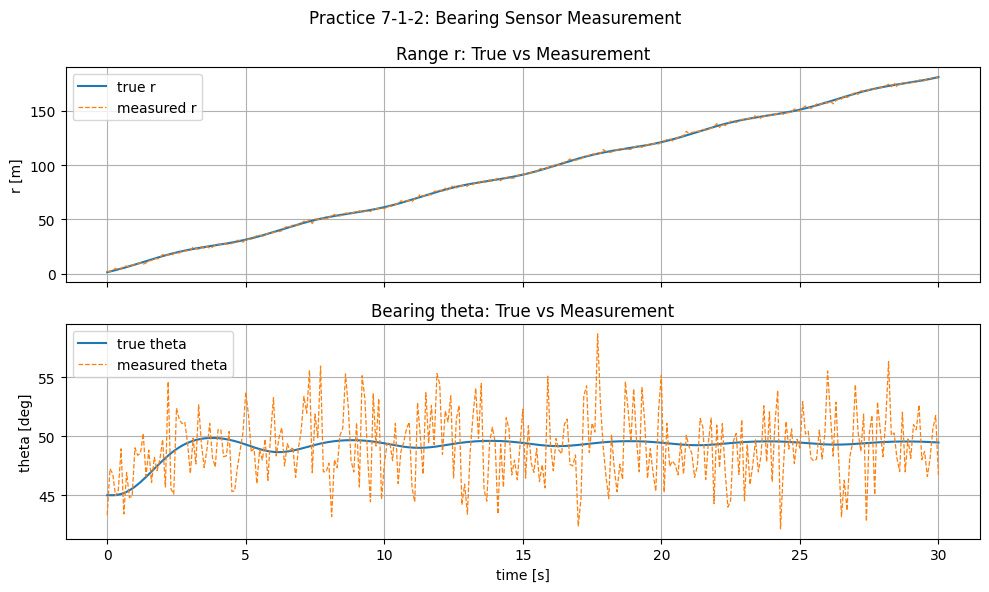

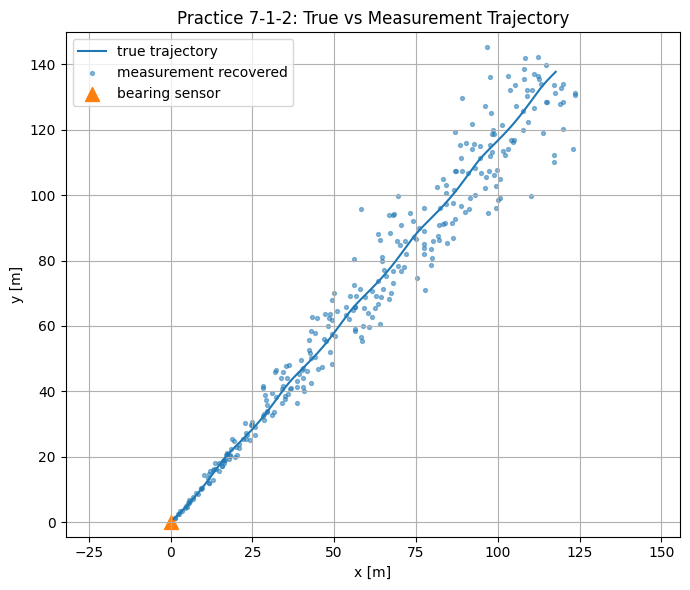

Practice 7-1-2 Result Check
y_history_true shape : (301, 2)
y_history shape      : (301, 2)
sigma_r              : 1.0000 m
sigma_theta          : 3.0000 deg
noise_r mean/std     : -0.0083 / 0.9821
noise_theta mean/std : -0.0576 / 2.8792 deg


In [7]:
# ============================================================
# Practice 7-1-2
# Bearing Sensor Measurement Simulation
# ============================================================

# ============================================================
# 1️⃣ 비선형 측정 함수 h(x) 정의
#    input : state = [x, y, psi]
#    output: measurement = [r, theta]
# ============================================================

def h_bearing(state):
    x = state[0]
    y = state[1]
    
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    
    return np.array([r, theta])

# ============================================================
# 2️⃣ 측정 노이즈 설정
#    문제 조건: range std = 1 m, bearing std = 3 deg
# ============================================================

np.random.seed(42)

sigma_r = 1.0
sigma_theta = np.deg2rad(3.0)

R = np.array([
    [sigma_r**2, 0.0],
    [0.0, sigma_theta**2]
])

noise_r = np.random.normal(0.0, sigma_r, N)
noise_theta = np.random.normal(0.0, sigma_theta, N)

# ============================================================
# 3️⃣ Measurement 생성
#    y_history_true: noise-free measurement
#    y_history     : noisy measurement
# ============================================================

y_history_true = np.zeros((N, 2))
y_history = np.zeros((N, 2))

for k in range(N):
    z_true = h_bearing(x_history[k])
    
    y_history_true[k, 0] = z_true[0]
    y_history_true[k, 1] = z_true[1]
    
    y_history[k, 0] = z_true[0] + noise_r[k]
    y_history[k, 1] = wrap_angle(z_true[1] + noise_theta[k])

# ============================================================
# 4️⃣ 결과 시각화 ① — range, bearing measurement
#    문제 요구: measurement simulation result
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(t, y_history_true[:, 0], label="true r", linewidth=1.5)
axes[0].plot(t, y_history[:, 0], "--", label="measured r", linewidth=0.9)
axes[0].set_title("Range r: True vs Measurement")
axes[0].set_ylabel("r [m]")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t, np.rad2deg(y_history_true[:, 1]), label="true theta", linewidth=1.5)
axes[1].plot(t, np.rad2deg(y_history[:, 1]), "--", label="measured theta", linewidth=0.9)
axes[1].set_title("Bearing theta: True vs Measurement")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("theta [deg]")
axes[1].grid(True)
axes[1].legend()

plt.suptitle("Practice 7-1-2: Bearing Sensor Measurement")
plt.tight_layout()
plt.show()

# ============================================================
# 5️⃣ 결과 시각화 ② — measurement를 x-y로 복원한 2D plot
#    문제 요구: measurement simulation result
# ============================================================

x_meas = y_history[:, 0] * np.cos(y_history[:, 1])
y_meas = y_history[:, 0] * np.sin(y_history[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(x_history[:, 0], x_history[:, 1], label="true trajectory", linewidth=1.5)
plt.scatter(x_meas, y_meas, s=8, alpha=0.5, label="measurement recovered")
plt.scatter(0.0, 0.0, marker="^", s=100, label="bearing sensor")
plt.title("Practice 7-1-2: True vs Measurement Trajectory")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 6️⃣ 결과 확인
# ============================================================

print("=" * 60)
print("Practice 7-1-2 Result Check")
print("=" * 60)
print(f"y_history_true shape : {y_history_true.shape}")
print(f"y_history shape      : {y_history.shape}")
print(f"sigma_r              : {sigma_r:.4f} m")
print(f"sigma_theta          : {np.rad2deg(sigma_theta):.4f} deg")
print(f"noise_r mean/std     : {np.mean(noise_r):.4f} / {np.std(noise_r):.4f}")
print(f"noise_theta mean/std : {np.rad2deg(np.mean(noise_theta)):.4f} / {np.rad2deg(np.std(noise_theta)):.4f} deg")
print("=" * 60)


Practice 7-2 PF Q Tuning Start
Practice 7-2 PF Q Tuning Finished
Practice 7-2 PF Best Q Result
Best sigma_V        = 0.3100 m/s
Best sigma_psidot   = 0.0060 rad/s
Best Position RMSE  = 0.224582 m
Practice 7-2 PF RMSE
RMSE Position X     : 0.250561 m
RMSE Position Y     : 0.195175 m
RMSE Heading Psi    : 0.006633 rad
Heading RMSE        : 0.380065 deg
Position RMSE       : 0.224582 m


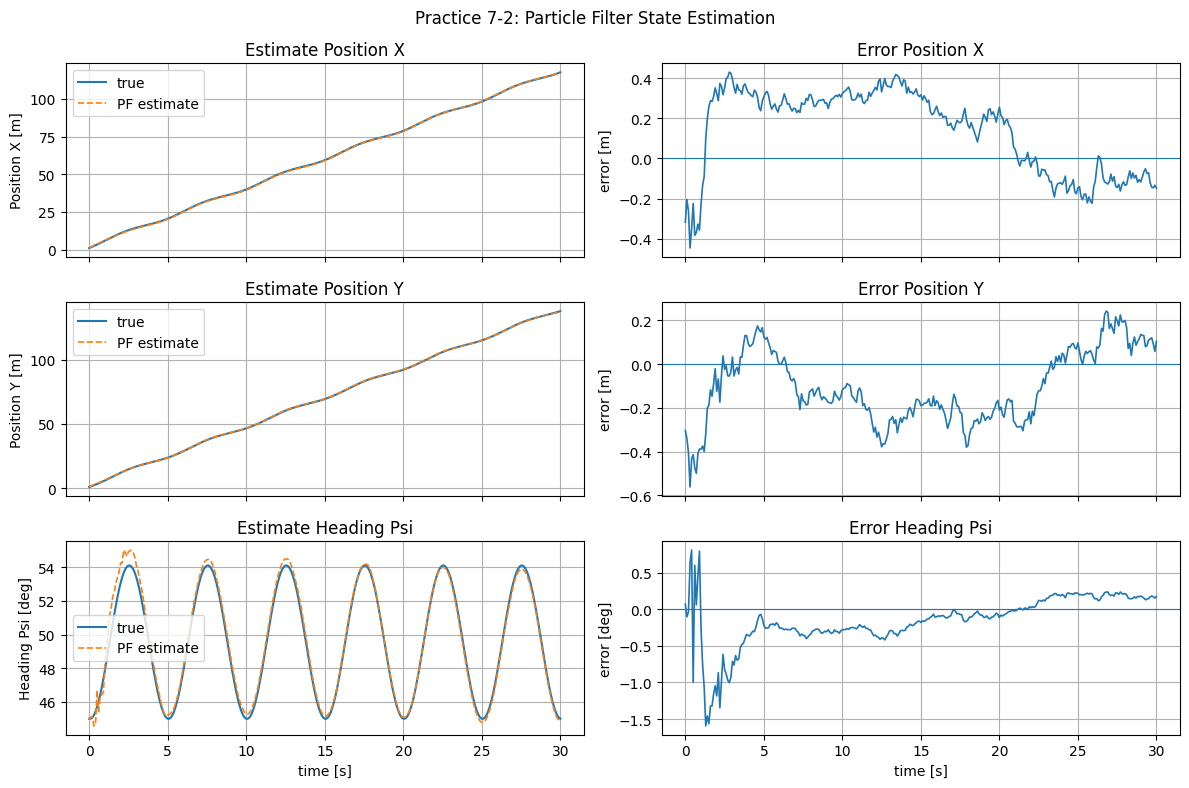

In [8]:
# ============================================================
# Practice 7-2
# Particle Filter with Dead Reckoning Model
# ============================================================

# ============================================================
# 1️⃣ Particle Filter 설정
# ============================================================

N_particles = 1000

# Q는 문제에서 직접 주어지지 않으므로 process uncertainty로 설계
# Dead Reckoning 입력 V, psi_dot의 불확실성을 Q_u로 두고 grid search 수행
# Q_u = diag(sigma_V^2, sigma_psidot^2)

sigma_V_list = np.round(np.arange(0.01, 1.00 + 0.01, 0.05), 4)
sigma_psidot_list = np.round(np.arange(0.001, 0.100 + 0.001, 0.005), 4)

# ============================================================
# 2️⃣ Particle Filter 보조 함수 정의
# ============================================================

def systematic_resampling(weights, rng):
    """
    Systematic resampling
    """
    M = len(weights)
    positions = (rng.random() + np.arange(M)) / M
    
    indexes = np.zeros(M, dtype=int)
    cumulative_sum = np.cumsum(weights)
    
    i = 0
    j = 0
    while i < M:
        if positions[i] < cumulative_sum[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1
            
    return indexes


def weighted_state_mean(particles, weights):
    """
    particles: (M, 3), state = [x, y, psi]
    weights  : (M,)
    """
    x_mean = np.sum(weights * particles[:, 0])
    y_mean = np.sum(weights * particles[:, 1])
    
    sin_mean = np.sum(weights * np.sin(particles[:, 2]))
    cos_mean = np.sum(weights * np.cos(particles[:, 2]))
    psi_mean = np.arctan2(sin_mean, cos_mean)
    
    return np.array([x_mean, y_mean, psi_mean])


def measurement_likelihood(z, z_pred):
    """
    Gaussian likelihood using R
    z      : (2,)
    z_pred : (M, 2)
    """
    residual = z.reshape(1, 2) - z_pred
    residual[:, 1] = np.array([wrap_angle(a) for a in residual[:, 1]])
    
    inv_R = np.linalg.inv(R)
    exponent = -0.5 * np.sum((residual @ inv_R) * residual, axis=1)
    
    # underflow 방지용 max shift
    exponent = exponent - np.max(exponent)
    likelihood = np.exp(exponent)
    
    return likelihood


def run_particle_filter(sigma_V, sigma_psidot, return_history=True, seed=7):
    """
    Particle Filter with Dead Reckoning Model
    
    Q 설계:
        input noise std = [sigma_V, sigma_psidot]
        V_particle       = V + N(0, sigma_V^2)
        psi_dot_particle = psi_dot + N(0, sigma_psidot^2)
    """
    rng = np.random.default_rng(seed)
    
    # --------------------------------------------------------
    # 초기 particle 생성
    # 첫 번째 bearing measurement를 Cartesian으로 변환하여 위치 초기화
    # --------------------------------------------------------
    r0 = y_history[0, 0]
    theta0 = y_history[0, 1]
    
    x0 = r0 * np.cos(theta0)
    y0 = r0 * np.sin(theta0)
    psi0 = np.deg2rad(45.0)
    
    particles = np.zeros((N_particles, 3))
    particles[:, 0] = x0 + rng.normal(0.0, 1.0, N_particles)
    particles[:, 1] = y0 + rng.normal(0.0, 1.0, N_particles)
    particles[:, 2] = wrap_angle(psi0 + rng.normal(0.0, np.deg2rad(5.0), N_particles))
    
    weights = np.ones(N_particles) / N_particles
    
    x_hat_pf = np.zeros((N, 3))
    x_hat_pf[0] = weighted_state_mean(particles, weights)
    
    # --------------------------------------------------------
    # PF loop
    # --------------------------------------------------------
    for k in range(1, N):
        # -----------------------------
        # Prediction
        # -----------------------------
        V_noisy = V[k - 1] + rng.normal(0.0, sigma_V, N_particles)
        psi_dot_noisy = psi_dot[k - 1] + rng.normal(0.0, sigma_psidot, N_particles)
        
        particles[:, 0] = particles[:, 0] + V_noisy * dT * np.cos(particles[:, 2])
        particles[:, 1] = particles[:, 1] + V_noisy * dT * np.sin(particles[:, 2])
        particles[:, 2] = wrap_angle(particles[:, 2] + psi_dot_noisy * dT)
        
        # -----------------------------
        # Weight update
        # -----------------------------
        z_k = y_history[k]
        
        r_pred = np.sqrt(particles[:, 0]**2 + particles[:, 1]**2)
        theta_pred = np.arctan2(particles[:, 1], particles[:, 0])
        z_pred = np.column_stack([r_pred, theta_pred])
        
        likelihood = measurement_likelihood(z_k, z_pred)
        weights = weights * likelihood
        
        weight_sum = np.sum(weights)
        if weight_sum < 1e-300:
            weights = np.ones(N_particles) / N_particles
        else:
            weights = weights / weight_sum
        
        # -----------------------------
        # State estimation
        # -----------------------------
        x_hat_pf[k] = weighted_state_mean(particles, weights)
        
        # -----------------------------
        # Resampling
        # -----------------------------
        N_eff = 1.0 / np.sum(weights**2)
        
        if N_eff < N_particles / 2.0:
            indexes = systematic_resampling(weights, rng)
            particles = particles[indexes]
            weights = np.ones(N_particles) / N_particles
    
    # --------------------------------------------------------
    # RMSE 계산
    # --------------------------------------------------------
    error = x_history - x_hat_pf
    error[:, 2] = np.array([wrap_angle(e) for e in error[:, 2]])
    
    rmse_state = np.sqrt(np.mean(error**2, axis=0))
    rmse_position = np.sqrt((rmse_state[0]**2 + rmse_state[1]**2) / 2.0)
    
    if return_history:
        return x_hat_pf, rmse_state, rmse_position
    else:
        return rmse_position

# ============================================================
# 3️⃣ Best Q 탐색
#    기준: Position RMSE 최소화
# ============================================================

RMSE_grid_pf = np.zeros((len(sigma_V_list), len(sigma_psidot_list)))

print("=" * 60)
print("Practice 7-2 PF Q Tuning Start")
print("=" * 60)

for i, sigma_V in enumerate(sigma_V_list):
    for j, sigma_psidot in enumerate(sigma_psidot_list):
        RMSE_grid_pf[i, j] = run_particle_filter(
            sigma_V=sigma_V,
            sigma_psidot=sigma_psidot,
            return_history=False,
            seed=7
        )

print("=" * 60)
print("Practice 7-2 PF Q Tuning Finished")
print("=" * 60)

min_idx = np.argmin(RMSE_grid_pf)
best_i_pf, best_j_pf = np.unravel_index(min_idx, RMSE_grid_pf.shape)

best_sigma_V_pf = sigma_V_list[best_i_pf]
best_sigma_psidot_pf = sigma_psidot_list[best_j_pf]
best_rmse_pos_pf = RMSE_grid_pf[best_i_pf, best_j_pf]

print("=" * 60)
print("Practice 7-2 PF Best Q Result")
print("=" * 60)
print(f"Best sigma_V        = {best_sigma_V_pf:.4f} m/s")
print(f"Best sigma_psidot   = {best_sigma_psidot_pf:.4f} rad/s")
print(f"Best Position RMSE  = {best_rmse_pos_pf:.6f} m")
print("=" * 60)

# ============================================================
# 4️⃣ Best Q로 PF 재실행
# ============================================================

x_hat_pf, rmse_pf, rmse_pos_pf = run_particle_filter(
    sigma_V=best_sigma_V_pf,
    sigma_psidot=best_sigma_psidot_pf,
    return_history=True,
    seed=7
)

print("=" * 60)
print("Practice 7-2 PF RMSE")
print("=" * 60)
print(f"RMSE Position X     : {rmse_pf[0]:.6f} m")
print(f"RMSE Position Y     : {rmse_pf[1]:.6f} m")
print(f"RMSE Heading Psi    : {rmse_pf[2]:.6f} rad")
print(f"Heading RMSE        : {np.rad2deg(rmse_pf[2]):.6f} deg")
print(f"Position RMSE       : {rmse_pos_pf:.6f} m")
print("=" * 60)

# ============================================================
# 5️⃣ 결과 시각화
#    문제 요구: estimated state and error plot
# ============================================================

labels_pf = ["Position X", "Position Y", "Heading Psi"]
units_plot = ["m", "m", "deg"]

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

for i in range(3):
    if i == 2:
        true_plot = np.rad2deg(x_history[:, i])
        est_plot = np.rad2deg(x_hat_pf[:, i])
        error_plot = np.rad2deg(np.array([wrap_angle(x_history[k, i] - x_hat_pf[k, i]) for k in range(N)]))
    else:
        true_plot = x_history[:, i]
        est_plot = x_hat_pf[:, i]
        error_plot = true_plot - est_plot
    
    axes[i, 0].plot(t, true_plot, label="true", linewidth=1.5)
    axes[i, 0].plot(t, est_plot, "--", label="PF estimate", linewidth=1.2)
    axes[i, 0].set_title(f"Estimate {labels_pf[i]}")
    axes[i, 0].set_ylabel(f"{labels_pf[i]} [{units_plot[i]}]")
    axes[i, 0].grid(True)
    axes[i, 0].legend()
    
    axes[i, 1].plot(t, error_plot, linewidth=1.2)
    axes[i, 1].axhline(0.0, linewidth=0.8)
    axes[i, 1].set_title(f"Error {labels_pf[i]}")
    axes[i, 1].set_ylabel(f"error [{units_plot[i]}]")
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel("time [s]")
axes[-1, 1].set_xlabel("time [s]")

plt.suptitle("Practice 7-2: Particle Filter State Estimation")
plt.tight_layout()
plt.show()


In [9]:
# ============================================================
# Practice 7-3
# Evaluation
# Compare RMSE of EKF-CV, EKF-DR, PF-DR
# ============================================================

# ============================================================
# 1️⃣ Practice 6에서 얻은 EKF RMSE 값 입력
#    필요 시 본인 Practice 6 결과값으로 수정
# ============================================================

rmse_pos_cv_ekf = 0.798013
rmse_pos_dr_ekf = 0.240993
rmse_pos_pf_dr = rmse_pos_pf

# ============================================================
# 2️⃣ RMSE 비교 출력
#    문제 요구: compare the RMSE
# ============================================================

comparison_rows = [
    ("Extended Kalman Filter with CV Model", rmse_pos_cv_ekf),
    ("Extended Kalman Filter with DR Model", rmse_pos_dr_ekf),
    ("Particle Filter with DR Model", rmse_pos_pf_dr),
]

print("=" * 80)
print("Practice 7-3: RMSE Comparison")
print("=" * 80)
print(f"{'Model':45s} | {'Position RMSE [m]':>18s}")
print("-" * 80)

for model_name, rmse_value in comparison_rows:
    print(f"{model_name:45s} | {rmse_value:18.6f}")

print("=" * 80)

# ============================================================
# 3️⃣ PF RMSE 상세 출력
# ============================================================

print("Particle Filter Detail")
print("-" * 80)
print(f"Best sigma_V        : {best_sigma_V_pf:.4f} m/s")
print(f"Best sigma_psidot   : {best_sigma_psidot_pf:.4f} rad/s")
print(f"PF RMSE Position X  : {rmse_pf[0]:.6f} m")
print(f"PF RMSE Position Y  : {rmse_pf[1]:.6f} m")
print(f"PF RMSE Heading Psi : {rmse_pf[2]:.6f} rad = {np.rad2deg(rmse_pf[2]):.6f} deg")
print(f"PF Position RMSE    : {rmse_pos_pf:.6f} m")
print("=" * 80)


Practice 7-3: RMSE Comparison
Model                                         |  Position RMSE [m]
--------------------------------------------------------------------------------
Extended Kalman Filter with CV Model          |           0.798013
Extended Kalman Filter with DR Model          |           0.240993
Particle Filter with DR Model                 |           0.224582
Particle Filter Detail
--------------------------------------------------------------------------------
Best sigma_V        : 0.3100 m/s
Best sigma_psidot   : 0.0060 rad/s
PF RMSE Position X  : 0.250561 m
PF RMSE Position Y  : 0.195175 m
PF RMSE Heading Psi : 0.006633 rad = 0.380065 deg
PF Position RMSE    : 0.224582 m
